In [1]:
import gc
import time
import gseapy as gp
import textwrap

from pathlib import Path

import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from matplotlib.lines import Line2D
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

from upsetplot import from_contents, generate_counts, UpSet, plot, from_indicators

import seaborn as sns

# import anndata as ad
# import scanpy as sc

%matplotlib inline

In [2]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [3]:
## Import Posterior Tests from mashR ##

dfn_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Dorsal_Forebrain_Neuron_FOXG1+EMX1+NEUROG1+_all.csv')
rg_vim_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+VIM+FABP7+_all.csv')
rg_pax_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+PAX6+FABP7+_all.csv')
mc_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mesenchymal-like_cells_VIM+VCAN+SPARC+_all.csv')
gaba_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_GABAergic_GAD1+GAD2+CALB2+_all.csv')
prg_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Proliferative_Radial_Glia_SOX2+HES6+TOP2A+_all.csv')
ipc_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_IPC_EOMES+NEUROG2+PAX6+_all.csv')
mn_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mixed_Neurons_FGF12+GRIN2B+CAMK2B+_all.csv')
astro_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Astrocyte_GFAP+AQP4+HOPX+_all.csv')

In [4]:
combined = pd.DataFrame({
    "gene": dfn_composite["gene"],
    "score_dfn": dfn_composite["score"],
    "score_rg_vim": rg_vim_composite["score"],
    "score_rg_pax": rg_pax_composite["score"],
    "score_mc": mc_composite["score"],
    "score_gaba": gaba_composite["score"],
    "score_prg": prg_composite["score"],
    "score_ipc": ipc_composite["score"],
    "score_mn": mn_composite["score"],
    "score_astro": astro_composite["score"],
})

combined = combined.set_index("gene")

combined.to_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/combined_composite_test.csv')

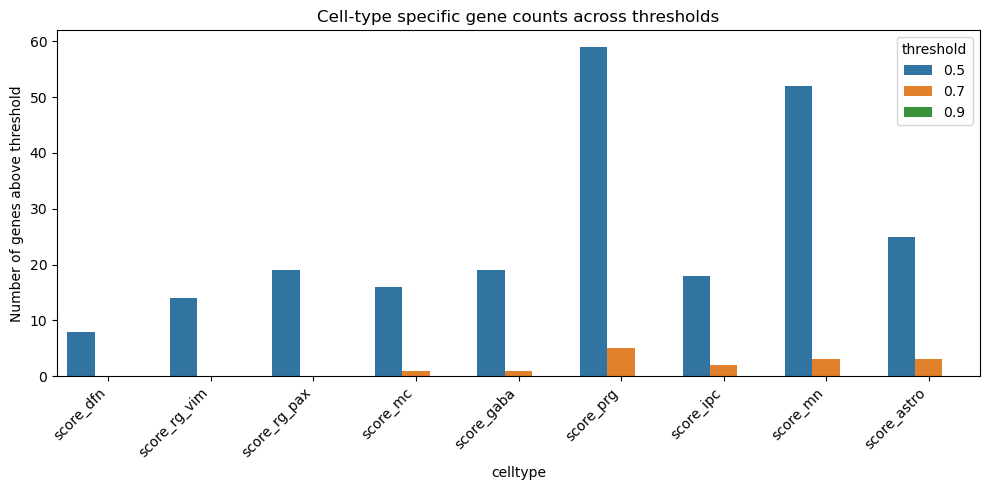

In [5]:
thresholds = [0.5, 0.7, 0.9]

data = []

for t in thresholds:
    counts = (combined > t).sum(axis=0)  # per cell type
    for celltype, value in counts.items():
        data.append({
            "celltype": celltype,
            "threshold": str(t),
            "count": value
        })

df = pd.DataFrame(data)


plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="celltype",
    y="count",
    hue="threshold"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of genes above threshold")
plt.title("Cell-type specific gene counts across thresholds")
plt.tight_layout()

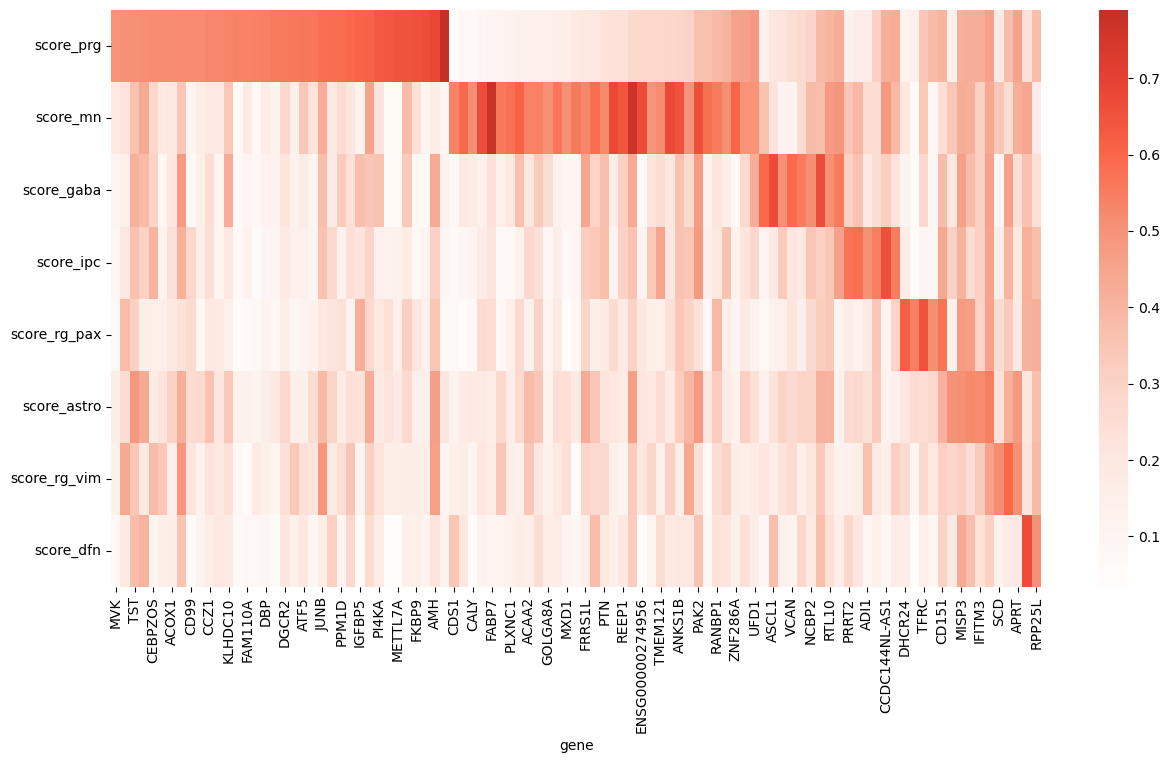

In [6]:
specific = combined[(combined > 0.5).sum(axis=1) == 1]

winner = (specific > 0.5).idxmax(axis=1)

# Count how many genes belong to each cell type
block_sizes = winner.value_counts()

# Order cell types from largest block to smallest
col_order = block_sizes.index.tolist()

# Reorder columns
specific = specific[col_order]

# Make winner a categorical with the desired ordering
winner = pd.Categorical(
    winner,
    categories=col_order,
    ordered=True
)

# Sort rows by block, then by score within each block
specific = (
    specific.assign(winner=winner)
            .sort_values(["winner"] + col_order, ascending=False)
            .drop(columns="winner")
)

specific = specific.iloc[::-1]

colors = [
    "#FFFDFC",
    "#FDF2EE",
    "#FDE4DC",
    "#FBCFC2",
    "#F7B29C",
    "#F69277",
    "#FA6648",
    "#E74334",
    "#C53024",
]

cmap = LinearSegmentedColormap.from_list(
    "custom_red",
    colors,
    N=256
)

plt.figure(figsize=(15,7.5))
sns.heatmap(
    specific.T,
    yticklabels=True,
    cmap=cmap)

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Figure_mashR_sensitivity_mashR_Heatmap.svg", bbox_inches="tight")

In [7]:
## Minus 15q13 ##

gaba_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_GABAergic_GAD1+GAD2+CALB2+_all.csv')
rg_vim_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Radial_Glia_SOX2+VIM+FABP7+_all.csv')
rg_pax_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Radial_Glia_SOX2+PAX6+FABP7+_all.csv')
mn_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Mixed_Neurons_FGF12+GRIN2B+CAMK2B+_all.csv')
ipc_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_IPC_EOMES+NEUROG2+PAX6+_all.csv')
dfn_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Dorsal_Forebrain_Neuron_FOXG1+EMX1+NEUROG1+_all.csv')
mc_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Mesenchymal-like_cells_VIM+VCAN+SPARC+_all.csv')
prg_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Proliferative_Radial_Glia_SOX2+HES6+TOP2A+_all.csv')
hindbrain_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Hindbrain_Neurons_NR2F2+PBX3+LHX1+_all.csv')
astro_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Astrocyte_GFAP+AQP4+HOPX+_all.csv')

In [8]:
combined_minus_15q13 = pd.DataFrame({
    "gene": dfn_comp_minus_15q13["gene"],
    "score_dfn": dfn_comp_minus_15q13["score"],
    "score_rg_vim": rg_vim_comp_minus_15q13["score"],
    "score_rg_pax": rg_pax_comp_minus_15q13["score"],
    "score_mc": mc_comp_minus_15q13["score"],
    "score_gaba": gaba_comp_minus_15q13["score"],
    "score_prg": prg_comp_minus_15q13["score"],
    "score_ipc": ipc_comp_minus_15q13["score"],
    "score_mn": mn_comp_minus_15q13["score"],
    "score_hindbrain": hindbrain_comp_minus_15q13["score"],
    "score_astro": astro_comp_minus_15q13["score"],
})

combined_minus_15q13 = combined_minus_15q13.set_index("gene")


combined_minus_15q13.to_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/combined_minus_15q13_composite_test.csv')

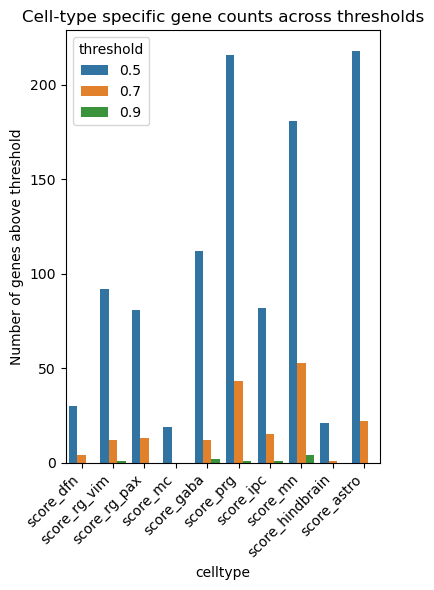

In [9]:
thresholds = [0.5, 0.7, 0.9]

data = []

for t in thresholds:
    counts = (combined_minus_15q13 > t).sum(axis=0)  # per cell type
    for celltype, value in counts.items():
        data.append({
            "celltype": celltype,
            "threshold": str(t),
            "count": value
        })

df = pd.DataFrame(data)


plt.figure(figsize=(4,6))

sns.barplot(
    data=df,
    x="celltype",
    y="count",
    hue="threshold"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of genes above threshold")
plt.title("Cell-type specific gene counts across thresholds")
plt.tight_layout()

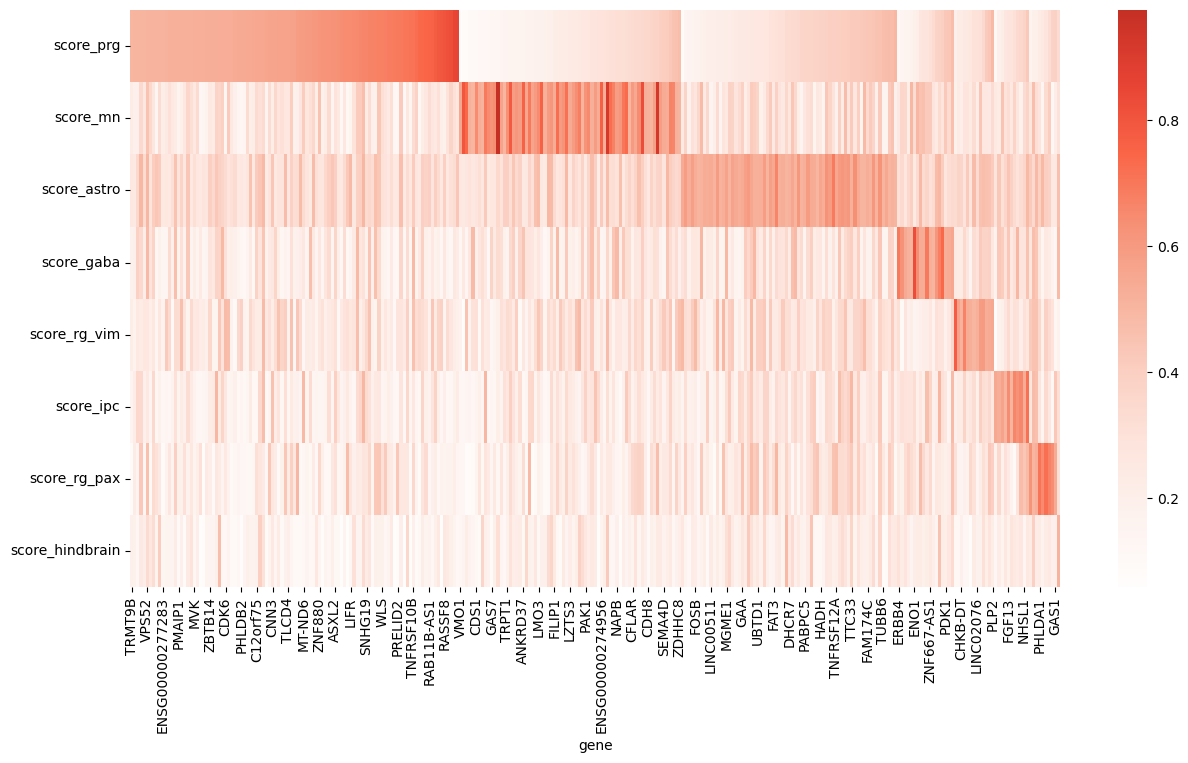

In [10]:
specific = combined_minus_15q13[(combined_minus_15q13 > 0.5).sum(axis=1) == 1]

winner = (specific > 0.5).idxmax(axis=1)

# Count how many genes belong to each cell type
block_sizes = winner.value_counts()

# Order cell types from largest block to smallest
col_order = block_sizes.index.tolist()

# Reorder columns
specific = specific[col_order]

# Make winner a categorical with the desired ordering
winner = pd.Categorical(winner, categories=col_order, ordered=True)

# Sort rows by block, then by score within each block
specific = specific.assign(winner=winner).sort_values(["winner"] + col_order, ascending=False).drop(columns="winner")

specific = specific.iloc[::-1]

colors = [
    "#FFFDFC",
    "#FDF2EE",
    "#FDE4DC",
    "#FBCFC2",
    "#F7B29C",
    "#F69277",
    "#FA6648",
    "#E74334",
    "#C53024",
]

cmap = LinearSegmentedColormap.from_list(
    "custom_red",
    colors,
    N=256
)

plt.figure(figsize=(15,7.5))
sns.heatmap(
    specific.T,
    yticklabels=True,
    cmap=cmap)

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Figure_mashR_sensitivity_mashR_Heatmap_minus_15q13.svg", bbox_inches="tight")

In [11]:
## Read in minus 3q29 and 15q13 ##

ipc_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_IPC_EOMES+NEUROG2+PAX6+_all.csv')
hindbrain_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Hindbrain_Neurons_NR2F2+PBX3+LHX1+_all.csv')
mn_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Mixed_Neurons_FGF12+GRIN2B+CAMK2B+_all.csv')
dfn_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Dorsal_Forebrain_Neuron_FOXG1+EMX1+NEUROG1+_all.csv')
mc_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Mesenchymal-like_cells_VIM+VCAN+SPARC+_all.csv')
rg_pax_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Radial_Glia_SOX2+PAX6+FABP7+_all.csv')
rg_vim_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Radial_Glia_SOX2+VIM+FABP7+_all.csv')
gaba_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_GABAergic_GAD1+GAD2+CALB2+_all.csv')
prg_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Proliferative_Radial_Glia_SOX2+HES6+TOP2A+_all.csv')
astro_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Astrocyte_GFAP+AQP4+HOPX+_all.csv')

In [12]:
combined_minus_3q29_15q13 = pd.DataFrame({
    "gene": dfn_comp_minus_3q29_15q13["gene"],
    "score_dfn": dfn_comp_minus_3q29_15q13["score"],
    "score_rg_vim": rg_vim_comp_minus_3q29_15q13["score"],
    "score_rg_pax": rg_pax_comp_minus_3q29_15q13["score"],
    "score_mc": mc_comp_minus_3q29_15q13["score"],
    "score_gaba": gaba_comp_minus_3q29_15q13["score"],
    "score_prg": prg_comp_minus_3q29_15q13["score"],
    "score_ipc": ipc_comp_minus_3q29_15q13["score"],
    "score_mn": mn_comp_minus_3q29_15q13["score"],
    "score_hindbrain": hindbrain_comp_minus_3q29_15q13["score"],
    "score_astro": astro_comp_minus_3q29_15q13["score"],
})

combined_minus_3q29_15q13 = combined_minus_3q29_15q13.set_index("gene")

combined_minus_3q29_15q13.to_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/combined_minus_3q29_15q13_composite_test.csv')

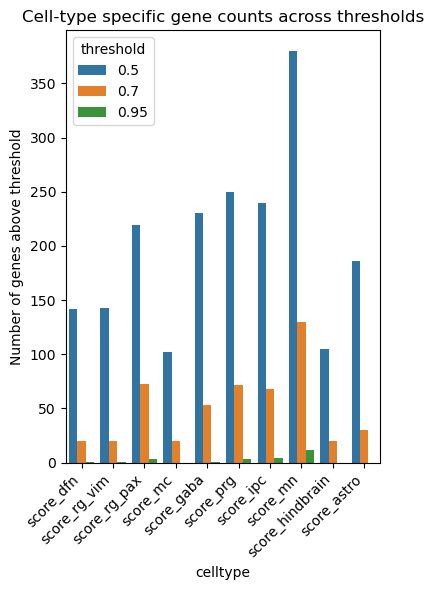

In [13]:
thresholds = [0.5, 0.7, 0.95]

data = []

for t in thresholds:
    counts = (combined_minus_3q29_15q13 > t).sum(axis=0)  # per cell type
    for celltype, value in counts.items():
        data.append({
            "celltype": celltype,
            "threshold": str(t),
            "count": value
        })

df = pd.DataFrame(data)


plt.figure(figsize=(4,6))

sns.barplot(
    data=df,
    x="celltype",
    y="count",
    hue="threshold"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of genes above threshold")
plt.title("Cell-type specific gene counts across thresholds")
plt.tight_layout()

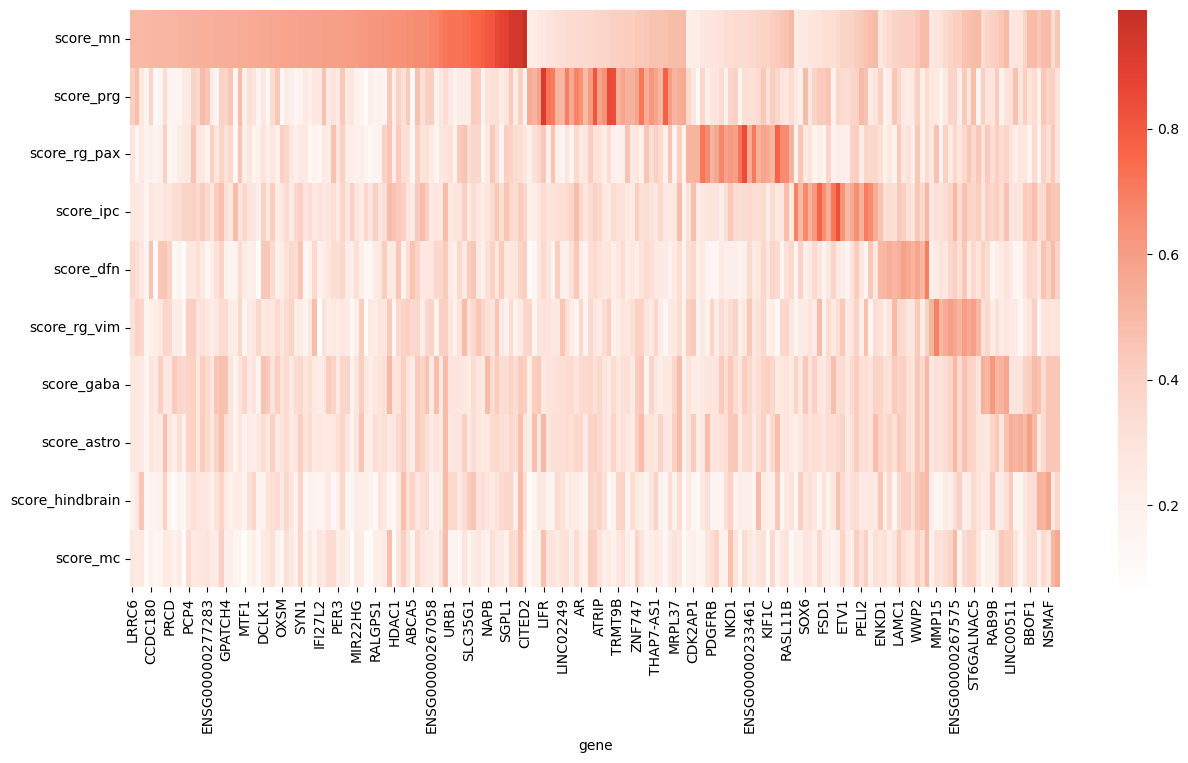

In [14]:
specific = combined_minus_3q29_15q13[(combined_minus_3q29_15q13 > 0.5).sum(axis=1) == 1]

winner = (specific > 0.5).idxmax(axis=1)

# Count how many genes belong to each cell type
block_sizes = winner.value_counts()

# Order cell types from largest block to smallest
col_order = block_sizes.index.tolist()

# Reorder columns
specific = specific[col_order]

# Make winner a categorical with the desired ordering
winner = pd.Categorical(winner, categories=col_order,  ordered=True)

# Sort rows by block, then by score within each block
specific = specific.assign(winner=winner).sort_values(["winner"] + col_order, ascending=False).drop(columns="winner")

specific = specific.iloc[::-1]

colors = ["#FFFDFC", "#FDF2EE", "#FDE4DC", "#FBCFC2", "#F7B29C", "#F69277", "#FA6648", "#E74334", "#C53024"]

cmap = LinearSegmentedColormap.from_list("custom_red", colors, N=256)

plt.figure(figsize=(15,7.5))

sns.heatmap(specific.T, yticklabels=True, cmap=cmap)

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Figure_mashR_sensitivity_mashR_Heatmap_minus_3q29_15q13.svg", bbox_inches="tight")